# Griffiths Problem 1.12 -- the needle's shadow, and why a sine wave's voltage is U-shaped
### the arcsine law $\rho(x)=\dfrac{1}{\pi\sqrt{r^2-x^2}}$, verified by SymPy and Torch

Same broken speedometer as Problem 1.11, but now we watch the **projection** (the shadow) of the
needle tip on the horizontal axis, $x=r\cos\theta$, with $\theta$ uniform on $[0,\pi]$. Because the
tip lingers near the ends of its swing, the projection piles up at $x=\pm r$: the density is the
**arcsine distribution**
$$\rho(x)=\frac{1}{\pi\sqrt{r^2-x^2}},\qquad -r<x<r,$$
which *diverges* (integrably) at the edges -- a U-shaped curve, not a flat one.

As before we **derive and `assert` every result in SymPy**, cross-check with a **Torch** Monte-Carlo,
and table it in **Pandas**. The payoff answers a question directly: the *same* arcsine law is the
histogram of a **sine wave's instantaneous voltage**. The needle's shadow (physics) and an AC
signal's samples (electrical engineering) are the identical distribution -- the EE-vs-physics line is
a coordinate change. Runs on the Python 3.12 + Torch kernel.

In [1]:
import sympy as sp
import numpy as np, torch, pandas as pd
import matplotlib.pyplot as plt
sp.init_printing()
r = sp.symbols('r', positive=True)
x = sp.symbols('x', real=True)
theta = sp.symbols('theta', real=True, nonnegative=True)
print("sympy", sp.__version__, "| torch", torch.__version__, "| pandas", pd.__version__)

sympy 1.14.0 | torch 2.11.0+cu128 | pandas 2.3.3


## (a) Change of variables: from a flat $\rho(\theta)$ to a U-shaped $\rho(x)$

The needle angle is uniform, $\rho(\theta)=1/\pi$. The projection is $x=r\cos\theta$, a one-to-one map
on $[0,\pi]$, so probability is conserved: $\rho(x)=\rho(\theta)\,|d\theta/dx|$. With
$\theta=\arccos(x/r)$, SymPy gives $d\theta/dx=-1/\sqrt{r^2-x^2}$, hence
$\rho(x)=\dfrac{1}{\pi\sqrt{r^2-x^2}}$. We confirm the derivative and that the density integrates
to 1 over $[-r,r]$ (the total is $\tfrac{2}{\pi}\sin^{-1}(1)=1$).

In [2]:
theta_of_x = sp.acos(x/r)                       # invert x = r cos(theta) on [0, pi]
dtheta_dx = sp.diff(theta_of_x, x)
assert sp.simplify(dtheta_dx + 1/sp.sqrt(r**2 - x**2)) == 0     # d(theta)/dx = -1/sqrt(r^2-x^2)

# rho(x) = rho(theta)*|dtheta/dx| = (1/pi)|dtheta/dx|.  Verify via the squared form so the
# sqrt branch / Abs doesn't trip SymPy: (pi*rho)^2 must equal (dtheta/dx)^2.
rho_target = 1/(sp.pi*sp.sqrt(r**2 - x**2))
assert sp.simplify((sp.pi*rho_target)**2 - dtheta_dx**2) == 0   # rho(x) = 1/(pi sqrt(r^2-x^2))

norm = sp.integrate(rho_target, (x, -r, r))
assert sp.simplify(norm - 1) == 0                             # total probability = 1
print("d(theta)/dx =", dtheta_dx, "  ->  rho(x) =", rho_target)
print("normalization  int_{-r}^{r} rho dx =", norm, " (=1)")

d(theta)/dx = -1/(r*sqrt(1 - x**2/r**2))   ->  rho(x) = 1/(pi*sqrt(r**2 - x**2))
normalization  int_{-r}^{r} rho dx = 1  (=1)


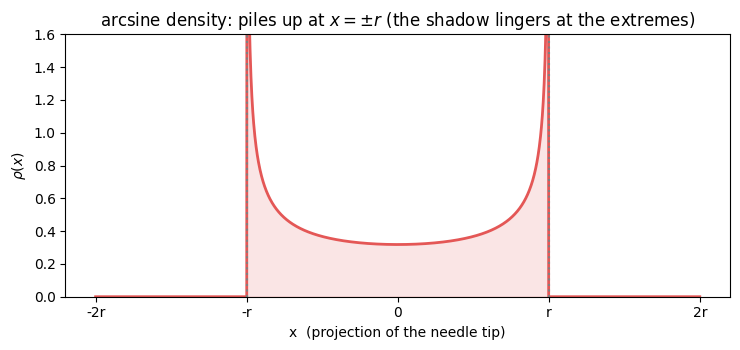

In [3]:
# Graph rho(x) from -2r to +2r (zero outside [-r, r]); U-shaped, diverging at the edges
rv = 1.0
xs = np.linspace(-2*rv, 2*rv, 2000)
inside = np.abs(xs) < rv*0.999
rho_num = np.zeros_like(xs)
rho_num[inside] = 1/(np.pi*np.sqrt(rv**2 - xs[inside]**2))
plt.figure(figsize=(7.5, 3.6))
plt.plot(xs, rho_num, color="#E45756", lw=2)
plt.fill_between(xs, rho_num, alpha=0.15, color="#E45756")
plt.axvline(-rv, ls=":", color="gray"); plt.axvline(rv, ls=":", color="gray")
plt.ylim(0, 1.6); plt.xticks([-2*rv,-rv,0,rv,2*rv], ["-2r","-r","0","r","2r"])
plt.xlabel("x  (projection of the needle tip)"); plt.ylabel(r"$\rho(x)$")
plt.title("arcsine density: piles up at $x=\\pm r$ (the shadow lingers at the extremes)")
plt.tight_layout(); plt.show()

## (b) $\langle x\rangle$, $\langle x^2\rangle$, $\sigma$ -- integrated exactly

$$\langle x\rangle=\int_{-r}^{r}\frac{x\,dx}{\pi\sqrt{r^2-x^2}}=0\ (\text{odd}),\quad
\langle x^2\rangle=\int_{-r}^{r}\frac{x^2\,dx}{\pi\sqrt{r^2-x^2}}=\frac{r^2}{2},\quad
\sigma=\frac{r}{\sqrt2}.$$

In [4]:
mean_x  = sp.integrate(x    * rho_target, (x, -r, r))
mean_x2 = sp.integrate(x**2 * rho_target, (x, -r, r))
var   = sp.simplify(mean_x2 - mean_x**2)
sigma = sp.simplify(sp.sqrt(var))

assert mean_x == 0
assert sp.simplify(mean_x2 - r**2/2) == 0
assert sp.simplify(sigma - r/sp.sqrt(2)) == 0
for name, val in [("<x>", mean_x), ("<x^2>", mean_x2), ("sigma^2", var), ("sigma", sigma)]:
    print(f"{name:8s} = {val}")

<x>      = 0


<x^2>    = r**2/2
sigma^2  = r**2/2
sigma    = sqrt(2)*r/2


## The shortcut from Problem 1.11(c): $\langle x^n\rangle=r^n\langle\cos^n\theta\rangle$

Because $x=r\cos\theta$, moments of $x$ are just moments of $\cos\theta$ from the *previous* problem:
$\langle x\rangle=r\langle\cos\theta\rangle=0$ and $\langle x^2\rangle=r^2\langle\cos^2\theta\rangle
=r^2\cdot\tfrac12=\tfrac{r^2}{2}$. No new integral needed -- SymPy confirms the $\theta$-integrals give
the same answers as the direct $x$-integrals above.

In [5]:
# compute the moments the *other* way: average over the uniform theta directly
mean_x_theta  = sp.integrate((r*sp.cos(theta))    * (1/sp.pi), (theta, 0, sp.pi))
mean_x2_theta = sp.integrate((r*sp.cos(theta))**2 * (1/sp.pi), (theta, 0, sp.pi))
assert mean_x_theta == 0                       # r * <cos theta> = r * 0
assert sp.simplify(mean_x2_theta - r**2/2) == 0    # r^2 * <cos^2 theta> = r^2 * 1/2
assert sp.simplify(mean_x_theta - mean_x) == 0 and sp.simplify(mean_x2_theta - mean_x2) == 0
print("<x>   via theta =", mean_x_theta,  " = r*<cos theta>   (matches direct integral)")
print("<x^2> via theta =", mean_x2_theta, " = r^2*<cos^2 theta> (matches direct integral)")

<x>   via theta = 0  = r*<cos theta>   (matches direct integral)
<x^2> via theta = r**2/2  = r^2*<cos^2 theta> (matches direct integral)


## Cross-check: Torch Monte-Carlo

Draw uniform angles, project to $x=r\cos\theta$, and both the **moments** and the **histogram**
should match the arcsine law. Watch the U-shape emerge from the samples.

<x>      torch -0.00024   exact +0.00000
<x^2>    torch +0.50013   exact +0.50000
sigma    torch +0.70720   exact +0.70711


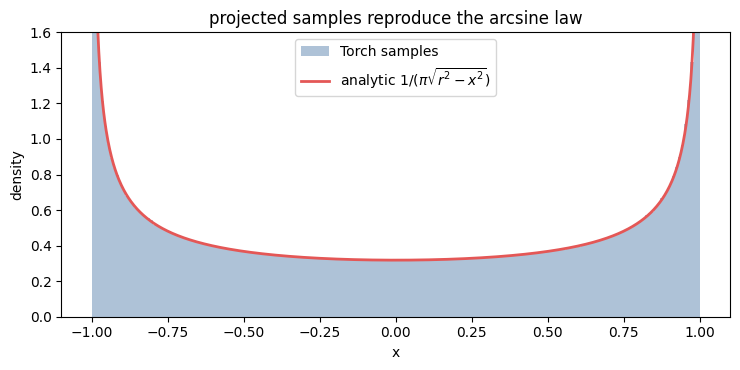

In [6]:
torch.manual_seed(0)
N = 4_000_000
rv = 1.0
th_s = torch.rand(N) * torch.pi
x_s = rv * torch.cos(th_s)                      # the projection
est = {"<x>": x_s.mean(), "<x^2>": (x_s**2).mean(), "sigma": x_s.std(unbiased=False)}
exact = {"<x>": 0.0, "<x^2>": rv**2/2, "sigma": rv/np.sqrt(2)}
for k in est:
    print(f"{k:7s}  torch {float(est[k]):+.5f}   exact {exact[k]:+.5f}")

# histogram of the samples vs the analytic arcsine density
fig, ax = plt.subplots(figsize=(7.5, 3.8))
ax.hist(x_s.numpy(), bins=200, range=(-rv, rv), density=True, alpha=0.45,
        color="#4C78A8", label="Torch samples")
xg = np.linspace(-rv*0.999, rv*0.999, 1000)
ax.plot(xg, 1/(np.pi*np.sqrt(rv**2 - xg**2)), color="#E45756", lw=2,
        label=r"analytic $1/(\pi\sqrt{r^2-x^2})$")
ax.set_ylim(0, 1.6); ax.set_xlabel("x"); ax.set_ylabel("density")
ax.set_title("projected samples reproduce the arcsine law"); ax.legend()
plt.tight_layout(); plt.show()

## Summary table (Pandas)

In [7]:
rows = []
for k in exact:
    ex, nm = float(exact[k]), float(est[k])
    rows.append({"quantity": k, "exact": round(ex, 5), "torch MC": round(nm, 5),
                 "abs error": f"{abs(nm-ex):.2e}", "match": abs(nm-ex) < 3e-3})
df = pd.DataFrame(rows)
print(df.to_string(index=False))
assert df["match"].all()
print("\n<x>=0, <x^2>=r^2/2, sigma=r/sqrt(2)  -- all confirmed.")

quantity   exact  torch MC abs error  match
     <x> 0.00000  -0.00024  2.42e-04   True
   <x^2> 0.50000   0.50013  1.30e-04   True
   sigma 0.70711   0.70720  9.18e-05   True

<x>=0, <x^2>=r^2/2, sigma=r/sqrt(2)  -- all confirmed.


## EE payoff: the arcsine law is a sine wave's voltage histogram

Sample a sinusoid $v(t)=A\cos(\omega t+\phi)$ at random times and the distribution of the values you
read off is **exactly** $\rho(v)=1/(\pi\sqrt{A^2-v^2})$ -- the same arcsine law, because $v$ is the
projection of a uniformly rotating phase, just like the needle's shadow. A sine wave spends most of
its time near its peaks, so an oscilloscope's voltage histogram (or an ADC's input-sample histogram)
is U-shaped. **This is the answer to "EE vs physics":** the broken speedometer and the AC signal are
the same equation, $x=r\cos\theta$, read in two vocabularies.

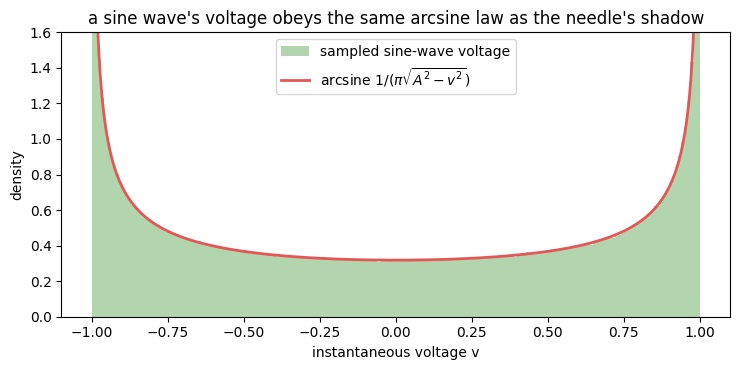

mean |v| RMS = 0.7071124315261841  ~ A/sqrt(2) = 0.7071067811865475  (the sinusoid RMS -- same r/sqrt(2) as sigma)


In [8]:
torch.manual_seed(1)
A = 1.0
phase = torch.rand(2_000_000) * 2*torch.pi       # sample a sine at random phase
v = A * torch.cos(phase)
plt.figure(figsize=(7.5, 3.8))
plt.hist(v.numpy(), bins=200, range=(-A, A), density=True, alpha=0.45, color="#54A24B",
         label="sampled sine-wave voltage")
vg = np.linspace(-A*0.999, A*0.999, 1000)
plt.plot(vg, 1/(np.pi*np.sqrt(A**2 - vg**2)), color="#E45756", lw=2,
         label=r"arcsine $1/(\pi\sqrt{A^2-v^2})$")
plt.ylim(0, 1.6); plt.xlabel("instantaneous voltage v"); plt.ylabel("density")
plt.title("a sine wave's voltage obeys the same arcsine law as the needle's shadow")
plt.legend(); plt.tight_layout(); plt.show()
print("mean |v| RMS =", float(v.pow(2).mean().sqrt()), " ~ A/sqrt(2) =", A/np.sqrt(2),
      " (the sinusoid RMS -- same r/sqrt(2) as sigma)")

## What we did

* Derived $\rho(x)=1/(\pi\sqrt{r^2-x^2})$ from $x=r\cos\theta$ by a SymPy **change of variables**,
  confirmed $d\theta/dx$ and normalization.
* Integrated **exactly**: $\langle x\rangle=0$, $\langle x^2\rangle=r^2/2$, $\sigma=r/\sqrt2$, each
  `assert`ed -- and showed the **shortcut** $\langle x^n\rangle=r^n\langle\cos^n\theta\rangle$ from
  Problem 1.11(c).
* Reproduced the density and moments with a **Torch** Monte-Carlo and a **Pandas** table.
* Recognized the arcsine law as a **sine wave's voltage distribution** -- the RMS $A/\sqrt2$ is the
  same $r/\sqrt2$ as $\sigma$. The needle problem and AC signal statistics are one and the same.

Continues `notebooks/griffiths_1_11_photonics.ipynb`: 1.11 gave $\langle\cos^n\theta\rangle$; 1.12
projects them onto the $x$-axis.